# Shear modulus reconstruction - overlapping inclusions (Fig 6.b, and 7.b)

In [ ]:
import dolfin as df
import math
import matplotlib.pyplot as plt
import numpy as np
import os

from Isotropic_case_forward_pb import isotropic_elasticity_problem
from Isotropic_case_VFM import VFM
%load_ext autoreload
%autoreload 2

### Parameters

In [2]:
omega, rho = 1, 1
degree = 3
dim = 2
Nx = 100
Ny = 100
u_boundary = df.Constant((0,0))  
T=  df.Expression(('0', '2*sin(2*pi*x[0])'), degree=1)

f = df.Constant((0,0))
tol = 1e-15

mesh_params = {"Nx":Nx, "Ny":Ny, "degree":degree}
load_params = {"u_boundary":u_boundary, "f":f ,"T":T}

mesh = df.UnitSquareMesh(Nx, Ny)
dx = df.Measure("dx", domain=mesh)
V_mu = df.FunctionSpace(mesh, 'CG', degree)

### True parameter mu

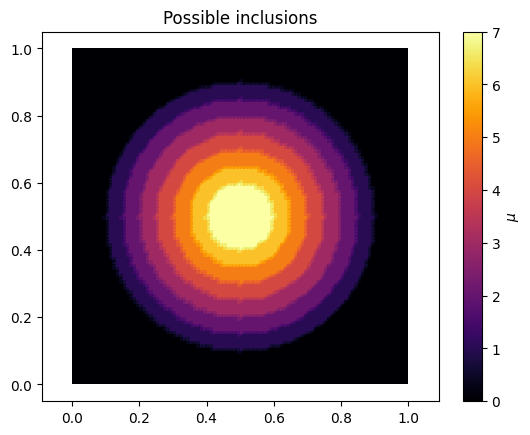

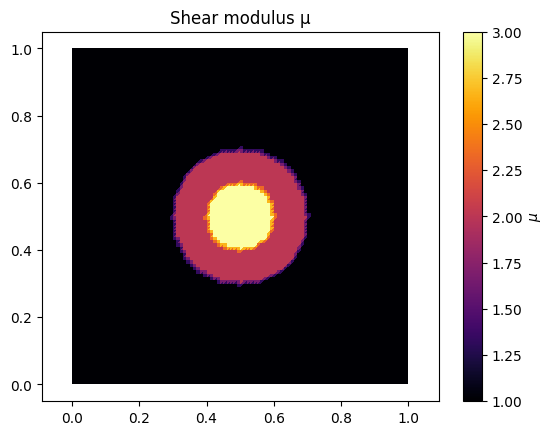

In [3]:
phi_list=[]
class PhiExpression(df.UserExpression):
    def __init__(self, r1=0.2, **kwargs):
        self.r1 = r1
        super().__init__(**kwargs)

    def eval(self, value, x):
        value[0] = 0
        if (x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2 <= self.r1 ** 2:
            value[0] = 1
phi_list = []

r1_values = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4 ]   

fct = df.Function(V_mu)
fct.vector() [:] = 0
for i in range(len(r1_values)):
    phi_exp = PhiExpression(r1=r1_values[i])
    phi_mn = df.interpolate(phi_exp, V_mu)
    phi_list.append(phi_mn)
    fct+= phi_mn

fct=df.project(fct,V_mu)
coords = mesh.coordinates()
values = fct.compute_vertex_values(mesh)
triangles = mesh.cells()
plt.tripcolor(coords[:, 0], coords[:, 1], triangles, values,
              shading="flat", cmap="inferno")
plt.colorbar(label=r"$\mu$")
plt.title("Possible inclusions")
plt.axis("equal")
plt.show()


class MuExpression(df.UserExpression):
    def eval(self, value, x):
        value[0] = 1
        if (x[0] - 0.5)**2 + (x[1] - 0.5)**2 <= 0.2**2:
            value[0] = 2
        if (x[0] - 0.5)**2 + (x[1] - 0.5)**2 <= 0.1**2:
            value[0] = 3          
    def value_shape(self):
        return ()

mu = df.interpolate(MuExpression(), V_mu)

coords = mesh.coordinates()
values = mu.compute_vertex_values(mesh)
triangles = mesh.cells()
plt.tripcolor(coords[:, 0], coords[:, 1], triangles, values,
              shading="flat", cmap="inferno")
plt.colorbar(label=r"$\mu$")
plt.title("Shear modulus μ")
plt.axis("equal")
plt.show()



### Direct problem

In [4]:
mat_params  = {"mu":mu, "rho":rho, "omega":omega}

ureal, mu_function, ureal_norm = isotropic_elasticity_problem(
    mesh_params=mesh_params,
    mat_params=mat_params,
    load_params=load_params)

Solving linear variational problem.


### PLot u

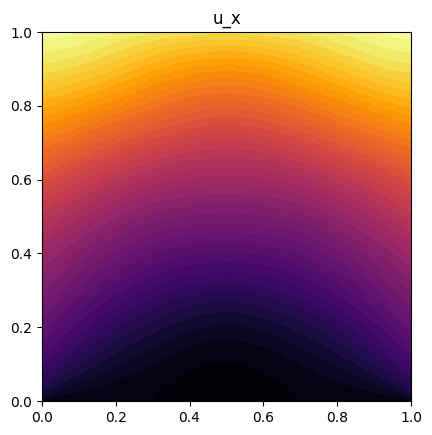

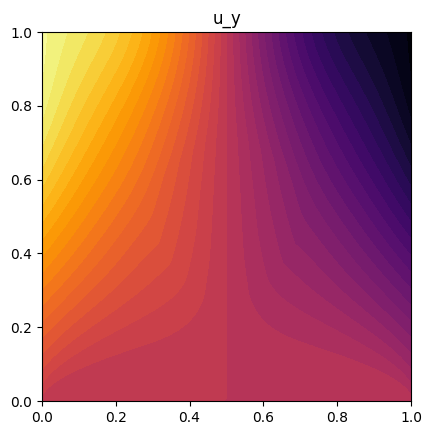

In [5]:
u1, u2 = ureal.split()
df.plot(u1, title="u_x", cmap="inferno")
plt.show()

df.plot(u2, title="u_y", cmap="inferno")
plt.show()

## Noiseless data

In [6]:
Error_list_Type1= []
SNR_list= [0]
V1 = ureal.function_space()
V_mu= mu_function.function_space()
mesh= V_mu.mesh()
dx = df.Measure("dx", domain=mesh)
          

Q= df.FiniteElement('CG', mesh.ufl_cell(), degree=degree - 1)
Q1 = df.FunctionSpace(mesh, Q)
V = df.VectorElement('CG', mesh.ufl_cell(), degree=degree)
V1 = df.FunctionSpace(mesh, V)
V_mu = df.FunctionSpace(mesh, 'CG', degree)

def epsilon(u):
    return 0.5*(df.nabla_grad(u) + df.nabla_grad(u).T) 

### Type 1

In [7]:
alpha=1e10
mu_rec= VFM(phi_list, ureal, V_mu, V, Q, alpha, rho, omega) 
norm1_l2 = math.sqrt(df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
print('L2-norm error, noiseless data :', norm1_l2) 
Error_list_Type1.append(norm1_l2*100)

Solving linear variational problem.
Values of m: [ 2.54510176e-06 -1.07334599e-07  4.23310754e-08 -4.71675122e-09
 -4.61837893e-09  5.97130519e-09]
Solving linear variational problem.
Values of m: [ 6.43474414e-06  3.44217072e-06  1.23517819e-07 -2.53009132e-08
 -9.95099733e-09  1.49018789e-08]
Solving linear variational problem.
Values of m: [-6.82967227e-07  8.66296177e-06  1.83279088e-06 -4.02554979e-08
 -2.11935271e-08 -7.06826415e-08]
Solving linear variational problem.
Values of m: [ 7.56977899e-07  8.73629679e-07  5.15082373e-06  4.42756656e-06
 -1.19931292e-07 -2.11297786e-08]
Solving linear variational problem.
Values of m: [-1.14796740e-07 -2.43554775e-07 -1.53975514e-07  6.02598136e-06
  4.36190663e-06 -8.09011893e-08]
Solving linear variational problem.
Values of m: [-1.52932059e-07 -1.30331517e-07 -1.10294051e-07 -2.22084161e-07
  5.93469977e-06  4.37274884e-06]
Solving linear variational problem.
Values of m: [ 4.24467469e-07  4.18976863e-07 -7.89637545e-07 -8.39935992e-0

## Stability w.r.t. noisy data

In [8]:
Noise_list = np.array( [ 0.025**2, 0.05**2, 0.075**2, 0.10**2, 0.15**2,  0.18**2, 0.20**2])
nb_noise = np.size(Noise_list)

h=ureal.vector().get_local()
a=h.shape 


In [9]:
for k in range(nb_noise) :  
    print("Noise = ", Noise_list[k])

    class noiseExpression(df.UserExpression):
        def eval(self, value, x):
           value[0]=0
           value[1]=0  
           for m  in range(1,10) :
                value[0] = value[0] +  Noise_list[k]*m/20*math.cos( 2*np.pi*x[0]*m/(20*math.sqrt(abs(Noise_list[k]))) )*math.cos( 2*np.pi*x[1]/(20*math.sqrt(abs( Noise_list[k]))) )*ureal_norm
                value[1] = value[1] + Noise_list[k]*m/20*math.cos( 2*np.pi*x[0]*m/(20*math.sqrt(abs( Noise_list[k]))) )*math.cos( 2*np.pi*x[1]/(20*math.sqrt(abs( Noise_list[k]))) )*ureal_norm
        def value_shape(self):
           return (2,)
    
    noise_Expression= noiseExpression()
    noise_Expression= df.interpolate(noise_Expression, V1) 
    u_noised= df.Function(V1)    
    u_noised.vector()[:] = ureal.vector()[:]+ noise_Expression.vector()[:] 

    SNR = math.sqrt(df.assemble((epsilon(ureal) - epsilon(u_noised))**2 * dx ) + df.assemble((ureal - u_noised)**2 * dx) )/ ureal_norm 
    SNR_list.append(SNR*100)
    print("SNR", SNR)

    #Type 1:
    mu_rec= VFM(phi_list, u_noised, V_mu, V, Q, alpha, rho, omega) 
    norm1_l2 = math.sqrt(df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
    Error_list_Type1.append(norm1_l2*100)
    print(f'L2-norm error, noisy data for SNR= {SNR}:', norm1_l2)

    

Noise =  0.0006250000000000001
SNR 0.030060523008805507
Solving linear variational problem.
Values of m: [ 2.64195564e-06 -1.10910457e-07  4.05215766e-08 -4.33381146e-09
 -4.26721206e-09  7.08916756e-09]
Solving linear variational problem.
Values of m: [ 6.46039402e-06  3.44086753e-06  1.22218173e-07 -2.54342702e-08
 -9.94037214e-09  1.48201540e-08]
Solving linear variational problem.
Values of m: [-6.83879883e-07  8.67644467e-06  1.83596781e-06 -4.07279815e-08
 -2.12371743e-08 -7.05362896e-08]
Solving linear variational problem.
Values of m: [ 7.02139133e-07  8.66042378e-07  5.15934502e-06  4.42958767e-06
 -1.21022070e-07 -2.13473708e-08]
Solving linear variational problem.
Values of m: [-1.02168480e-07 -2.45206916e-07 -1.55715725e-07  6.02661404e-06
  4.36426609e-06 -8.12740427e-08]
Solving linear variational problem.
Values of m: [-1.36834256e-07 -1.30352621e-07 -1.10443461e-07 -2.23964067e-07
  5.93628730e-06  4.37324876e-06]
Solving linear variational problem.
Values of m: [ 4.881

In [10]:
print(SNR_list)
print(Error_list_Type1)

[0, 3.0060523008805506, 6.012524300853479, 8.396576356443965, 12.036027872170472, 19.482942126906284, 27.035128846711082, 32.95130888190484]
[3.4737255321778895e-09, 2.196409474256271, 1.0725736202746952, 1.7270868807259057, 1.223093628848203, 5.206250311672962, 9.981136134595902, 24.292165283388236]


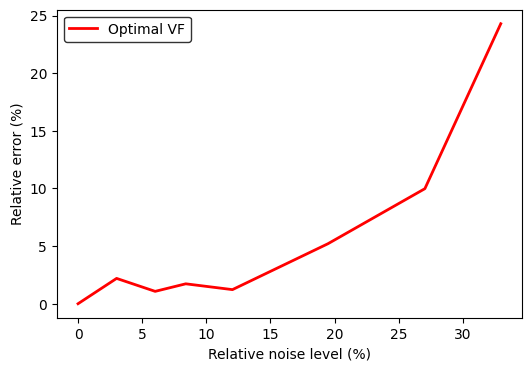

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))   

ax.plot(SNR_list, Error_list_Type1, "-r", label="Optimal VF", linewidth=2)

ax.set_xlabel('Relative noise level (%)')
ax.set_ylabel('Relative error (%)')

ax.legend(frameon=True, edgecolor="black", facecolor="white", fontsize=10,
         title_fontsize=10)


plt.show()
